# FastOTF2 Converter Benchmark

One-click comparison of the **fastotf2** converter against **Python** and **C**
converters, measuring the wall-clock time to convert OTF2 traces to tabular output.

| Tool | CSV | Parquet |
|------|-----|---------|
| fastotf2 | ✓ | ✓ |
| Python (`otf2` + pyarrow) | ✓ | ✓ |
| C (OTF2 C library) | ✓ | — (Arrow toolchain out of scope) |

All three converters ship inside **one Apptainer container**, so they use an identical
OTF2 version and the workflow is portable: the only host requirements are Apptainer + SLURM
and readable trace paths.

**All configuration lives in the config cell below** — there is no external config file.

Every conversion here runs on a **single node**, and each trace is **keyed by its capture
node count** (its identity) but **labelled and graphed by size on disk** — e.g. `11.6 GiB` —
so every graph and table is about data size, not node count. Internally the per-job label is
`s<nodes>_<size>GiB` (e.g. `s16_11.6GiB`) so two traces that round to the same size never
collide; the analysis strips the node prefix for display.

## How runs are organised

Each execution of the **config cell (§0)** mints a fresh timestamped `RUN_TAG` and its own
folder under `out/`, so runs never clobber each other:

```
out/run_YYYYMMDD_HHMMSS/
  config.json      # exact parameters used (provenance)
  run_logs/        # the generated per-job .sbatch scripts that were submitted
  results.csv      # timings for this run
  slurm_logs/      # SLURM stdout/stderr for this run
  scratch/         # conversion output (deleted between runs; large)
  plots/           # rendered table + chart
```

- **New run:** Run All (or run §0→§3). A new `RUN_DIR` is created and submitted.
- **Re-analyse a previous run** (no new data): restart the kernel, run the §0 imports, then
  in §4 set `ANALYZE_RUN = "run_YYYYMMDD_HHMMSS"` (a tag or a path) and run the analysis
  cells. Nothing is resubmitted.
- **Resubmit while another run is going:** a running dependency chain is independent, so you
  can restart this kernel and launch a fresh run at any time — they write to different folders.

> Which traces run is controlled by **`TRACES_TO_INCLUDE`** in §0 (a list of node counts,
> each validated against the selected system's `trace_inputs`). The default is the five
> single-HPL-run traces (**2 → 32 nodes**); the 128-/384-node captures are TB-scale and much
> slower, so add `128` / `384` there only when you want them.


# 0. Configuration & run folder

Everything you might change lives in this one cell. Running it creates a new timestamped
run folder under `out/`. Set `DRY_RUN = True` to preview submission without launching.

**`SYSTEM`** picks which cluster's settings to use (`"frontier"` or `"other-ex"`) — the
trace paths, SLURM partition, fastotf2 thread count, and `sbatch` account/mail extras all
follow from this one switch via `SYSTEM_CONFIGS`. The Slurm **account** and **mail** address
are secrets and are never hardcoded here — create a gitignored `local_secrets.py` in the
repo root with `SLURM_ACCOUNT` / `SLURM_MAIL_USER` (env vars work too, but only if set
before the Jupyter server process itself starts — an already-running kernel won't pick up a
shell `export` after the fact). On Frontier these become `--account=…` plus
`--mail-type=BEGIN,END,FAIL --mail-user=…` on every job.


In [ ]:
import os, json, shlex, subprocess, time
from pathlib import Path
from datetime import datetime

import workflows

REPO_DIR = Path.cwd()
assert (REPO_DIR / "benchmark" / "run_one.sh").exists(), \
    f"Run this notebook from the repo root; benchmark/run_one.sh not found in {REPO_DIR}"

# ======================== USER CONFIGURATION ========================
# --- Which system are we running on? ---------------------------------------
# Flip this ONE line to switch clusters; everything system-specific (trace paths,
# SLURM partition, fastotf2 thread count, and the sbatch account/mail extras) lives in
# SYSTEM_CONFIGS below, so nothing else in the notebook needs to change.
SYSTEM = "frontier"   # "frontier" | "other-ex"

# --- Secrets (never hardcode these in the notebook) -------------------------
# Preferred: a gitignored local_secrets.py in the repo root, since env vars exported in a
# terminal are NOT inherited by an already-running Jupyter kernel/server (exporting them
# and restarting the kernel does nothing -- you'd have to fully relaunch the process that
# started Jupyter). local_secrets.py sidesteps that:
#   SLURM_ACCOUNT   = "csc688"
#   SLURM_MAIL_USER = "you@example.com"
# Falls back to SLURM_ACCOUNT / SLURM_MAIL_USER env vars if that file doesn't exist.
try:
    from local_secrets import SLURM_ACCOUNT, SLURM_MAIL_USER
except ImportError:
    SLURM_ACCOUNT   = os.environ.get("SLURM_ACCOUNT")
    SLURM_MAIL_USER = os.environ.get("SLURM_MAIL_USER")


def _account_sbatch_args():
    return [f"--account={SLURM_ACCOUNT}"] if SLURM_ACCOUNT else []


def _mail_sbatch_args():
    return (["--mail-type=BEGIN,END,FAIL", f"--mail-user={SLURM_MAIL_USER}"]
            if SLURM_MAIL_USER else [])


# --- Container image (build target + what the benchmark runs against) ---
# Use the freshly-rebuilt image (adds the Python progress heartbeat + fast-tools-first
# combo order). It is a SEPARATE file from container/fastotf2-bench.sif, which a
# previously-launched job may still be using -- so pointing here does not disturb it.
IMAGE       = REPO_DIR / "container" / "fastotf2-bench-next.sif"
BASE_IMAGE  = "ghcr.io/hpc-ai-adv-dev/fastotf2/fastotf2-converter:latest"  # portable, single-locale

# --- Per-system configuration ------------------------------------------------
# trace_inputs: a dict {traced_nodes: path} (same shape as the scaling notebook), where each
#   path is a directory that directly contains the OTF2 anchor (traces.otf2). The node count
#   is the trace's IDENTITY end-to-end; its on-disk size in GiB (measured with du -sb) is
#   carried alongside only as a display label (the graphs show size on disk, not node count).
#   NB: the Frontier HPL captures don't share one layout -- the 2/4/8-node anchors sit at the
#   top level of their dir, but the 16/32-node ones live in a results/ subdir, so those keys
#   point at .../<run>/results (the dir that actually holds traces.otf2).
# partition: blank -> the cluster's default (Frontier's is `batch`).
# chpl_threads: fastotf2 threads per locale; 0 = all node cores.
# sbatch_extra_args: account + mail (from secrets) on Frontier; none elsewhere.
SYSTEM_CONFIGS = {
    "frontier": {
        "trace_inputs": {
            2:   "/lustre/orion/csc688/world-shared/scorep-amd/runs/scratch/4098287/frontier-2-node-single-HPL-run",
            4:   "/lustre/orion/csc688/world-shared/scorep-amd/runs/scratch/4098294/frontier-4-node-single-HPL-run",
            8:   "/lustre/orion/csc688/world-shared/scorep-amd/runs/scratch/4098296/frontier-8-node-single-HPL-run",
            16:  "/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-16-node-single-HPL-run/results",
            32:  "/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-32-node-single-HPL-run/results",
            128: "/lustre/orion/csc688/world-shared/scorep-amd/runs/scorep-rocHPL/experiments/one-cabinet",
            384: "/lustre/orion/csc688/world-shared/scorep-amd/runs/scorep-rocHPL/experiments/three-cabinet",
        },
        "partition":         "",     # blank -> Frontier's default (batch)
        "chpl_threads":      56,
        "sbatch_extra_args": _account_sbatch_args() + _mail_sbatch_args(),
    },
    "other-ex": {
        "trace_inputs": {
            2:   "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run",
            4:   "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-4-node-single-HPL-run",
            8:   "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-8-node-single-HPL-run",
            16:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run",
            32:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-32-node-single-HPL-run",
            128: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-128-node-single-HPL-run",
            384: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-384-node-single-HPL-run",
        },
        "partition":         "",
        "chpl_threads":      0,
        "sbatch_extra_args": [],
    },
}

_cfg = SYSTEM_CONFIGS[SYSTEM]
if SYSTEM == "frontier" and not (SLURM_ACCOUNT and SLURM_MAIL_USER):
    raise RuntimeError(
        "SYSTEM='frontier' needs SLURM_ACCOUNT and SLURM_MAIL_USER -- create a gitignored "
        "local_secrets.py in the repo root with those two variables, or set them as "
        "environment variables before the Jupyter server process itself is started."
    )

TRACE_INPUTS = _cfg["trace_inputs"]   # {traced_nodes: trace directory}
TRACE_ANCHOR = "traces.otf2"

# Which traces (by their capture node count) to actually benchmark this run -- the SINGLE
# source of truth for trace selection. Every entry MUST be a key of the selected system's
# trace_inputs (validated below), so this behaves identically on both systems. Default: the
# five single-HPL-run traces (2->32 nodes). The 128-/384-node captures (one-/three-cabinet)
# are TB-scale and take far longer, so they're left out by default -- add 128 and/or 384
# here to include them.
TRACES_TO_INCLUDE = [2, 4, 8, 16, 32]

_unknown = [n for n in TRACES_TO_INCLUDE if n not in TRACE_INPUTS]
if _unknown:
    raise ValueError(
        f"TRACES_TO_INCLUDE {_unknown} not defined in SYSTEM_CONFIGS['{SYSTEM}']['trace_inputs'] "
        f"(available node counts: {sorted(TRACE_INPUTS)}).")

# --- Which (tool, format) combos to run. Each becomes its OWN SLURM job; jobs are
#     dependency-chained in §2 so they run one-at-a-time (clean, non-contending timings).
#     "fastotf2" is the container's default converter; run_one.sh maps it to
#     `apptainer run <sif>`. ---
COMBOS = [
    ("fastotf2", "CSV"), ("fastotf2", "PARQUET"),
    ("c",        "CSV"),
    ("python",   "CSV"), ("python",   "PARQUET"),
]

REPEATS      = 1                   # timed repeats per combo (averaged in analysis)
CHPL_THREADS = _cfg["chpl_threads"]  # fastotf2 threads per locale; 0 = all node cores

# --- SLURM ---
SLURM_PARTITION   = _cfg["partition"]     # blank -> cluster default
SLURM_TIME        = "2:00:00"
SLURM_EXCLUSIVE   = True
SBATCH_EXTRA_ARGS = _cfg["sbatch_extra_args"]   # account + mail (from secrets) on Frontier

# --- Preview without submitting? ---
DRY_RUN = False
# ====================================================================

# --- Fresh, timestamped run folder (never clobbers a previous run) ---
RUN_TAG = f"run_{datetime.now():%Y%m%d_%H%M%S}"
OUT_ROOT = REPO_DIR / "out"
RUN_DIR  = OUT_ROOT / RUN_TAG
for sub in ("slurm_logs", "run_logs", "timings", "scratch", "plots"):
    (RUN_DIR / sub).mkdir(parents=True, exist_ok=True)
TIMINGS_DIR = RUN_DIR / "timings"      # one small CSV per conversion job
RESULTS_CSV = RUN_DIR / "results.csv"  # merged from timings/ after jobs finish

# --- Measure each included trace's on-disk size with the SHARED helper
#     (workflows.measure_trace_sizes_gib) -- the SAME function the scaling notebook uses, so
#     the two notebooks ALWAYS report an identical size (du -sb, GiB = 1024**3). Cached to
#     the run's trace_sizes.json. Identity stays the node count; the label "s<nodes>_<size>GiB"
#     carries the size, and the graphs later relabel by size-on-disk only. ---
_sizes = workflows.measure_trace_sizes_gib(
    {n: TRACE_INPUTS[n] for n in sorted(TRACES_TO_INCLUDE)}, RUN_DIR / "trace_sizes.json")
TRACES = {}          # traced_nodes -> {"path", "gib", "label"}
for _nodes in sorted(TRACES_TO_INCLUDE):
    _gib = _sizes[_nodes]
    TRACES[_nodes] = {"path": TRACE_INPUTS[_nodes], "gib": _gib,
                      "label": f"s{_nodes}_{_gib:.1f}GiB"}

CONFIG = {
    "run_tag": RUN_TAG, "system": SYSTEM, "image": str(IMAGE), "base_image": BASE_IMAGE,
    "trace_anchor": TRACE_ANCHOR, "traces_to_include": TRACES_TO_INCLUDE,
    "traces": {n: {"label": t["label"], "gib": round(t["gib"], 3), "path": t["path"]}
               for n, t in TRACES.items()},
    "combos": [f"{t}|{f}" for t, f in COMBOS], "repeats": REPEATS,
    "chpl_threads": CHPL_THREADS,
    "slurm": {"account": SLURM_ACCOUNT, "partition": SLURM_PARTITION,
              "time": SLURM_TIME, "exclusive": SLURM_EXCLUSIVE,
              "extra_args": SBATCH_EXTRA_ARGS},
}
(RUN_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2))

print(f"SYSTEM  : {SYSTEM}")
print(f"RUN_TAG : {RUN_TAG}")
print(f"RUN_DIR : {RUN_DIR}")
print(f"IMAGE   : {IMAGE}")
print("traces  :")
for _nodes in sorted(TRACES):
    _t = TRACES[_nodes]
    print(f"    s{_nodes:<3} {_t['label']:>14}  {_t['path']}")
print(f"combos  : {', '.join(f'{t}({f})' for t, f in COMBOS)}")
print(f"jobs    : {len(TRACES) * len(COMBOS) * REPEATS} (one SLURM job each, dependency-chained)")
print(f"DRY_RUN : {DRY_RUN}")


# 1. Container image

Builds the bench image if `IMAGE` does not exist yet (one-time, ~minutes). Uses the
cached base image; installs the Python stack and compiles the C converter inside.

In [ ]:
if IMAGE.exists():
    print("Bench image present:", IMAGE)
else:
    print("Bench image missing — building it now (one-time)...")
    env = {**os.environ, "BENCH_SIF": str(IMAGE),
           "BENCH_IMAGE_TAG": "localhost/fastotf2-bench:latest",
           "BENCH_BASE_IMAGE": BASE_IMAGE}
    subprocess.run(["bash", str(REPO_DIR / "container" / "build-bench-image.sh")],
                   cwd=REPO_DIR, env=env, check=True)
    print("Build complete:", IMAGE)

# 2. Build & submit the benchmark to SLURM (one job per conversion)

Each `(trace, tool, format, repeat)` is submitted as its **own exclusive** single-node SLURM
job, but the jobs are **dependency-chained** (`--dependency afterany:<prev>`) so they run
**one-at-a-time** — the same strategy as the scaling notebook. These conversions are
I/O-heavy, so running them in parallel would make them contend for the shared filesystem and
pollute each other's wall-clock timings; serial execution keeps every measurement clean.
Every job writes its own one-row timing CSV under `timings/`, and its generated
`run_logs/<tag>.sbatch` is saved for provenance. With `DRY_RUN = True`, scripts are written
and the exact chained `sbatch` commands are printed, but nothing is submitted.


In [ ]:
import itertools

def sbatch_for(trace_label, trace_dir, tool, fmt, rep):
    """Text of a per-conversion sbatch script (config baked in for provenance)."""
    tag = f"{trace_label}_{tool}_{fmt}_r{rep}"
    result_file = TIMINGS_DIR / f"{tag}.csv"
    out_dir     = RUN_DIR / "scratch" / tag
    lines = ["#!/usr/bin/env bash",
             f"#SBATCH --job-name=f2b-{RUN_TAG}-{tag}",
             "#SBATCH --nodes=1",
             f"#SBATCH --time={SLURM_TIME}",
             f"#SBATCH --output={RUN_DIR}/slurm_logs/{tag}-%j.out",
             f"#SBATCH --error={RUN_DIR}/slurm_logs/{tag}-%j.err"]
    if SLURM_EXCLUSIVE:
        lines.append("#SBATCH --exclusive")
    if SLURM_PARTITION:
        lines.append(f"#SBATCH --partition={SLURM_PARTITION}")
    # Account + mail (from local_secrets, via SYSTEM_CONFIGS) are baked in as #SBATCH
    # directives so each saved script is a faithful record of what was submitted.
    for _extra in SBATCH_EXTRA_ARGS:
        lines.append(f"#SBATCH {_extra}")
    lines += [
        "",
        f"export BENCH_SIF={shlex.quote(str(IMAGE))}",
        f"export BENCH_RUN_TAG={shlex.quote(RUN_TAG)}",
        f"export BENCH_TRACE_DIR={shlex.quote(trace_dir)}",
        f"export BENCH_TRACE_LABEL={shlex.quote(trace_label)}",
        f"export BENCH_TOOL={shlex.quote(tool)}",
        f"export BENCH_FORMAT={shlex.quote(fmt)}",
        f"export BENCH_REPEAT={rep}",
        f"export BENCH_OUTPUT_DIR={shlex.quote(str(out_dir))}",
        f"export BENCH_RESULT_FILE={shlex.quote(str(result_file))}",
        f"export BENCH_TRACE_ANCHOR={shlex.quote(TRACE_ANCHOR)}",
        f"export BENCH_CHPL_THREADS={CHPL_THREADS}",
        "",
        f"bash {shlex.quote(str(REPO_DIR / 'benchmark' / 'run_one.sh'))}",
        "",
    ]
    return tag, "\n".join(lines)


# One job per (trace, tool, format, repeat). Traces are iterated by node count (their
# identity), so every included trace launches exactly one job per combo -- no silent drops
# from label collisions. Jobs are DEPENDENCY-CHAINED (--dependency afterany:<prev>) so they
# run strictly one-at-a-time -- same strategy as the scaling notebook. These conversions are
# I/O-heavy, so running them in parallel would make them contend for the shared filesystem
# and pollute each other's wall-clock timings; serial execution keeps every measurement clean.
jobs, manifest = [], []
prev_job_id = None
for traced_nodes, (tool, fmt), rep in itertools.product(
        sorted(TRACES), COMBOS, range(1, REPEATS + 1)):
    spec = TRACES[traced_nodes]
    tag, script = sbatch_for(spec["label"], spec["path"], tool, fmt, rep)
    sb_path = RUN_DIR / "run_logs" / f"{tag}.sbatch"
    sb_path.write_text(script)

    sbatch_cmd = ["sbatch", "--parsable"]
    if prev_job_id is not None:
        sbatch_cmd += ["--dependency", f"afterany:{prev_job_id}"]
    sbatch_cmd.append(str(sb_path))

    if DRY_RUN:
        jobs.append({"tag": tag, "job_id": None})
        dep = f" (after {prev_job_id})" if prev_job_id is not None else " (chain head)"
        print(f"[dry] would submit {tag}{dep}\n        {' '.join(sbatch_cmd)}")
        prev_job_id = f"<{tag}>"   # keep the chain visible in the preview
        continue

    res = subprocess.run(sbatch_cmd, cwd=REPO_DIR, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"sbatch failed for {tag}:\n{res.stderr}")
    jid = res.stdout.strip().split(";")[0]
    jobs.append({"tag": tag, "job_id": jid})
    manifest.append(f"{jid},{tag}")
    print(f"submitted {jid}  {tag}" + (f"  (after {prev_job_id})" if prev_job_id else ""))
    prev_job_id = jid

JOB_IDS = [j["job_id"] for j in jobs if j["job_id"]]
(RUN_DIR / "manifest.csv").write_text("job_id,tag\n" + "".join(m + "\n" for m in manifest))
if DRY_RUN:
    print(f"\nDRY_RUN=True — nothing submitted. {len(jobs)} job(s) previewed; "
          "per-job scripts written under run_logs/.")
else:
    print(f"\nSubmitted {len(JOB_IDS)} dependency-chained jobs for run {RUN_TAG} "
          "(they run one-at-a-time).")
    print(f"Manifest: {RUN_DIR / 'manifest.csv'}")


# 3. Monitor the queue (optional)

Jobs run one-at-a-time via the dependency chain, so timing CSVs appear one-by-one under
`timings/`. The widget below is a live `squeue` monitor (press **Start**): RUNNING jobs show
time-left to walltime, WAITING jobs show their estimated start + priority, and **Force Kill**
runs `scancel --me`. Or call `wait_until_my_jobs_finished()` to block until the chain is
done. Nothing here is required for the analysis — §4 reads whatever CSVs already exist.


In [ ]:
from workflows import watch_queue_widget, wait_until_my_jobs_finished

# Live squeue monitor (press Start): RUNNING jobs with time-left, WAITING jobs with their
# estimated start + priority, and a Force Kill (scancel --me). Safe to skip -- nothing here
# is required for the analysis, which reads whatever timing CSVs already exist.
watch_queue_widget()

# Or, to block this cell until the whole dependency chain has drained, run:
# wait_until_my_jobs_finished()


# 4. Results analysis

**Self-contained** — needs only a run's `results.csv`, so you can restart the kernel and run
just this section.

- `ANALYZE_RUN = None` → the run created above this session; if the kernel is fresh, the
  most recent run under `out/`.
- `ANALYZE_RUN = "run_YYYYMMDD_HHMMSS"` (a tag) or a full path → analyse that **previous**
  run without collecting new data.

In [ ]:
import re
from pathlib import Path
import pandas as pd
from plotnine import *  # noqa: F401,F403

# === Which run to analyse? ===
# None -> the run created above this session (or the latest under out/ on a fresh kernel).
# tag  -> a previous run's tag, e.g. "run_20260714_101500", or a full path.
ANALYZE_RUN = None
ANALYZE_RUN = "/lustre/orion/csc688/scratch/shreyask/fastotf2-bench/out/run_20260717_215321"

_OUT_ROOT = (REPO_DIR / "out") if "REPO_DIR" in globals() else (Path.cwd() / "out")

def resolve_run_dir(analyze_run):
    if analyze_run:
        p = Path(analyze_run)
        if not p.exists():
            p = _OUT_ROOT / analyze_run
        return p.parent if p.is_file() else p
    if "RUN_DIR" in globals():
        return Path(globals()["RUN_DIR"])
    runs = sorted(_OUT_ROOT.glob("run_*/timings"))
    if not runs:
        raise FileNotFoundError(f"No runs with timings/ under {_OUT_ROOT}")
    return runs[-1].parent

ANALYSIS_DIR = resolve_run_dir(ANALYZE_RUN)
PLOTS_DIR = ANALYSIS_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

tfiles = sorted((ANALYSIS_DIR / "timings").glob("*.csv"))
if not tfiles:
    raise FileNotFoundError(f"No per-job timing CSVs under {ANALYSIS_DIR / 'timings'}")
df = pd.concat([pd.read_csv(f) for f in tfiles], ignore_index=True)
print(f"Analysing run: {ANALYSIS_DIR.name}  ({len(df)} rows from {len(tfiles)} jobs)")
if (df["status"] != 0).any():
    print("WARNING: some conversions failed (status != 0):")
    print(df[df["status"] != 0][["trace", "tool", "format", "status"]].to_string(index=False))

ok = df[df["status"] == 0].copy()
agg = (ok.groupby(["trace", "tool", "format"], as_index=False)
         .agg(seconds=("seconds", "mean"), output_bytes=("output_bytes", "mean")))

# The per-job "trace" label is "s<nodes>_<size>GiB" (e.g. "s16_11.6GiB"). Pull the size from
# the digits right before "GiB" so the leading node count is never mistaken for the size...
agg["gib"] = agg["trace"].str.extract(r"([\d.]+)GiB").astype(float)

# ...then relabel by SIZE ON DISK ONLY (no node count) for every table/graph below. This uses
# the SAME formula as the scaling notebook's size_label(), so both notebooks print an
# identical size (e.g. "11.6 GiB", not "12 GiB"): GiB (1024**3) with one decimal, TiB above 1024.
def size_on_disk(g):
    return f"{g / 1024:.2f} TiB" if g >= 1024 else f"{g:.1f} GiB"

agg["trace"] = agg["gib"].map(size_on_disk)

# Tool display names: keep the product name "fastotf2" as-is; Python/C capitalised.
_TOOL_DISP = {"fastotf2": "fastotf2", "python": "Python", "c": "C"}
agg["combo"] = agg["tool"].map(lambda t: _TOOL_DISP.get(t, t.capitalize())) + " (" + agg["format"] + ")"

# Ordered categoricals: traces ascending by real size; combos in a fixed reading order.
_trace_order = list(dict.fromkeys(agg.sort_values("gib")["trace"]))
agg["trace"] = pd.Categorical(agg["trace"], categories=_trace_order, ordered=True)
_combo_order = [c for c in ["fastotf2 (CSV)", "fastotf2 (PARQUET)", "C (CSV)",
                            "Python (CSV)", "Python (PARQUET)"] if c in set(agg["combo"])]
agg["combo"] = pd.Categorical(agg["combo"], categories=_combo_order, ordered=True)

# Save figures next to the run (kept alongside its data for provenance).
def _maybe_save(p, name, save=True):
    if save:
        p.save(PLOTS_DIR / f"{name}.png", dpi=150, verbose=False)

# Wide table for a quick numeric read-out (rows sorted by trace size on disk).
table = (agg.pivot(index="trace", columns="combo", values="seconds").reindex(columns=_combo_order))
table.columns.name = None
table.index.name = "size on disk"
print("\nSingle-node conversion time (seconds), mean over repeats:")
table.round(2)


In [ ]:
# Speedup over the Python baseline, per format (tidy long form for plotnine).
_recs = []
_piv = agg.pivot_table(index=["trace", "gib"], columns=["format", "tool"],
                       values="seconds", observed=True)
for (trace, gib), row in _piv.iterrows():
    for fmt in row.index.get_level_values(0).unique():
        block = row[fmt]
        if "python" not in block or pd.isna(block.get("python")):
            continue
        for tool in block.index:
            if tool == "python" or pd.isna(block[tool]):
                continue
            _recs.append({"trace": trace, "gib": gib,
                          "comparison": f"{_TOOL_DISP.get(tool, tool.capitalize())} ({fmt})",
                          "speedup": block["python"] / block[tool]})

speedup_long = pd.DataFrame(_recs)
if not speedup_long.empty:
    speedup_long["trace"] = pd.Categorical(speedup_long["trace"],
                                           categories=_trace_order, ordered=True)
    speedup_long = speedup_long.sort_values(["gib", "comparison"])
    print("Speedup over Python (x faster):")
    display(speedup_long.pivot(index="trace", columns="comparison", values="speedup").round(1))
else:
    print("No Python baseline available yet — speedup will appear once Python rows land.")


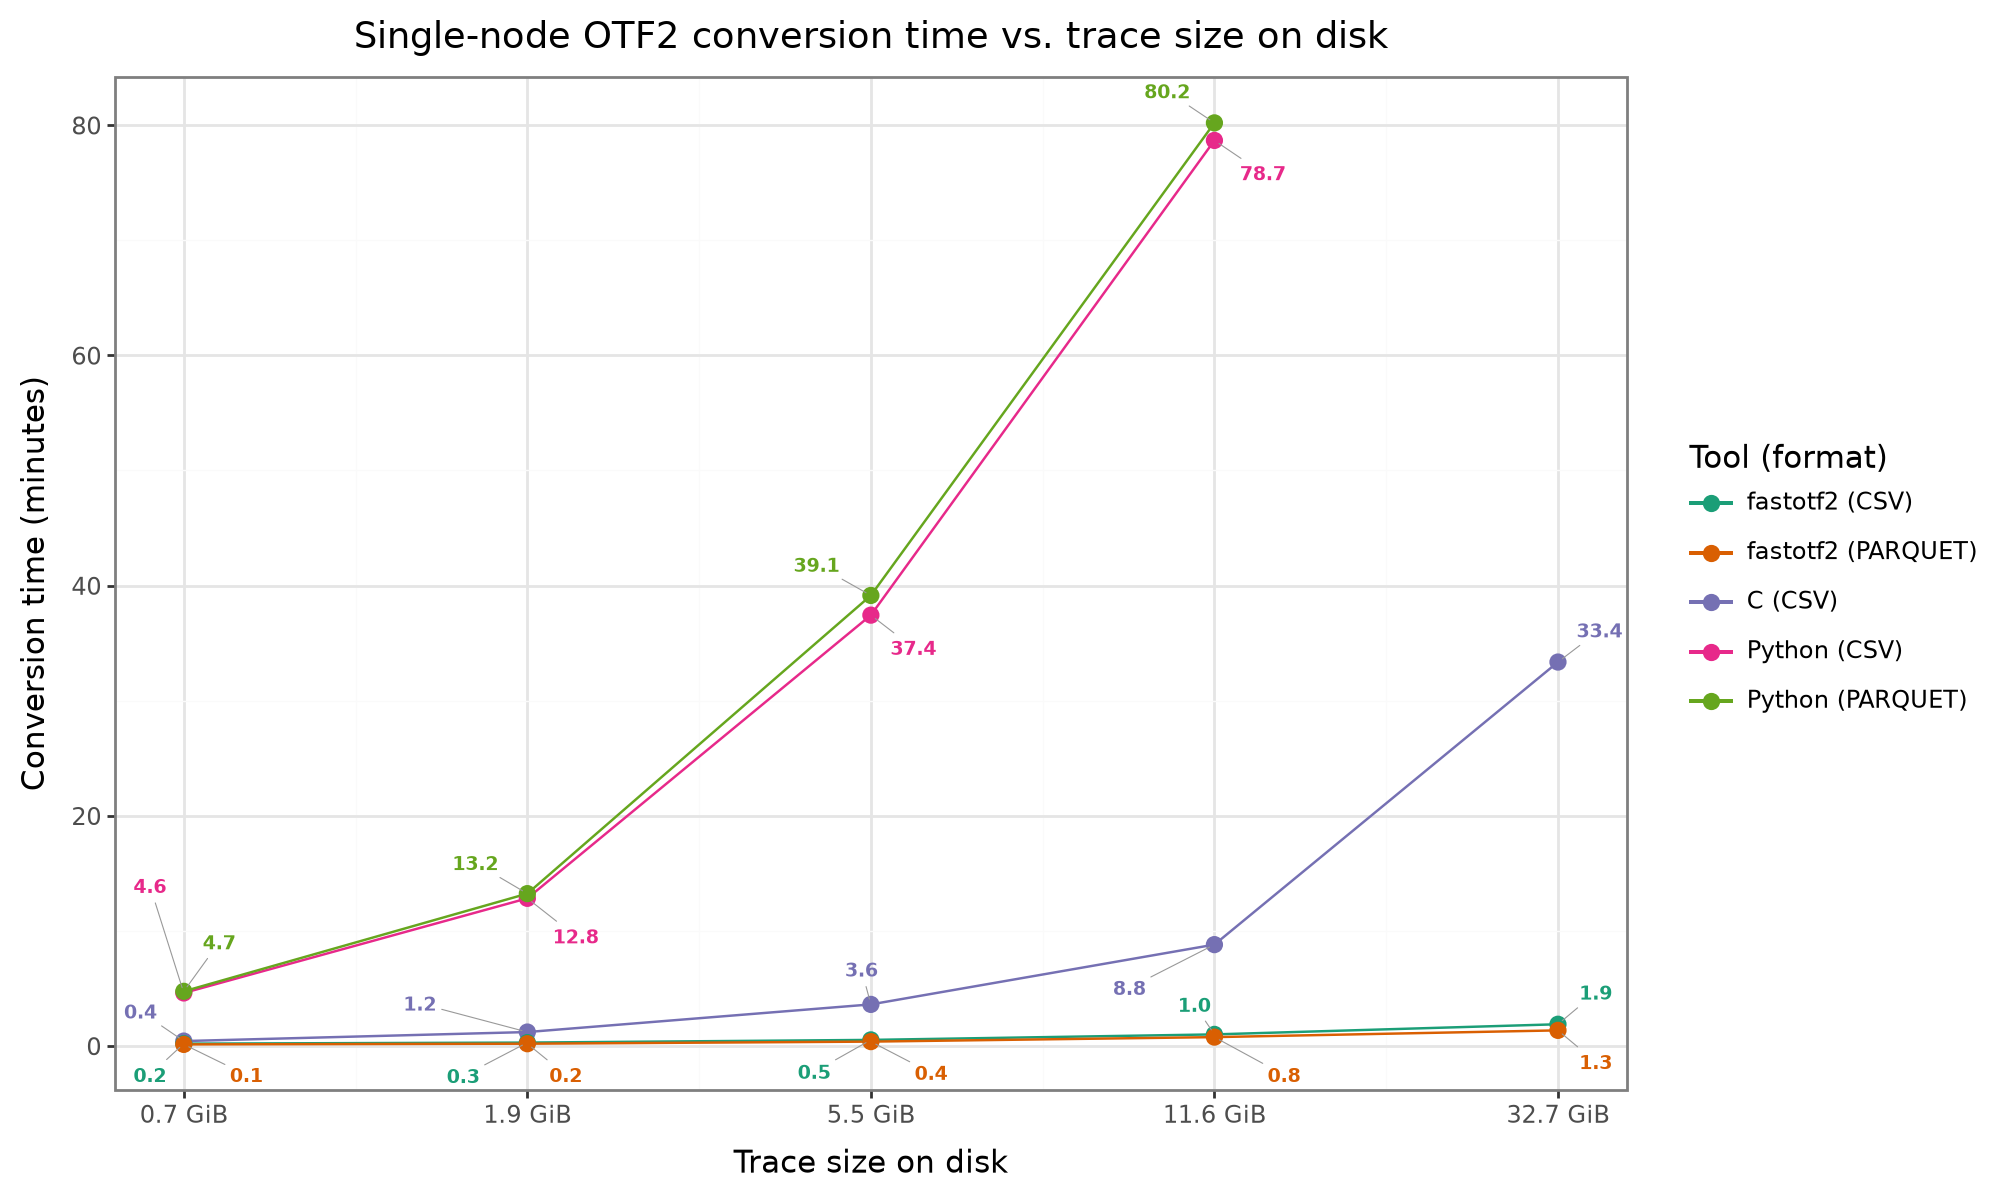

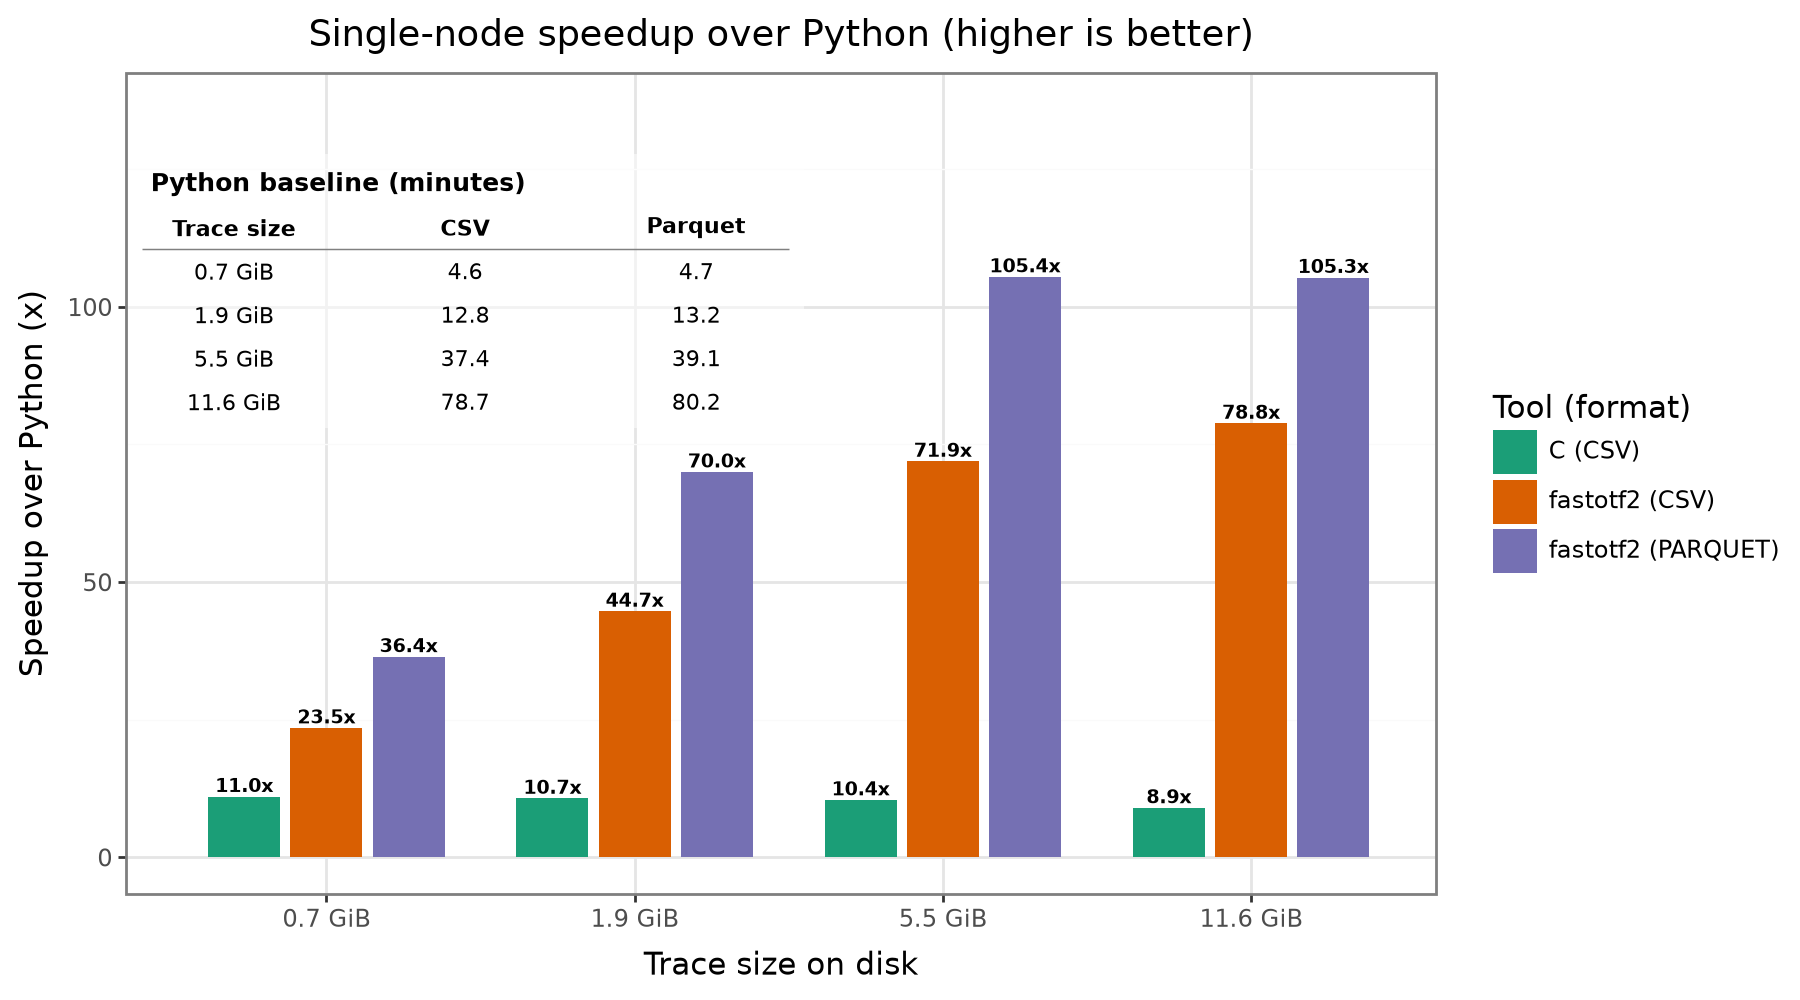

In [25]:
# --- Graphs (plotnine only), following the scaling-notebook conventions. All conversions
# here run on a SINGLE node, so the x-axis is the trace's SIZE ON DISK (not node count). ---
# G1: conversion time vs trace size on disk, in MINUTES on a LINEAR y-axis (a log axis
# visually compresses the huge fastotf2-vs-Python gap and understates the real speedup).
# Points + connecting lines show the trend; each point gets a data label coloured to MATCH
# its series, and adjustText repels the near-overlapping fastotf2/C labels apart, drawing a
# thin leader line back to each point so they stay legible.
agg = agg.copy()
agg["minutes"] = agg["seconds"] / 60.0
agg["min_label"] = agg["minutes"].map(lambda v: f"{v:.1f}")
# adjustText can only repel labels (and draw leader lines) on a CONTINUOUS axis, so map each
# trace to an integer x-position and relabel the ticks with the size strings.
_xpos = {t: i for i, t in enumerate(_trace_order)}
agg["xpos"] = agg["trace"].map(_xpos).astype(float)
# Densely sample points ALONG each series' line segments. adjustText's x/y args are "extra
# points to repel from" (they need NOT match the number of labels), so feeding it these makes
# the labels avoid the connecting LINES -- not just each other and the data points.
import numpy as np
_avoid_x, _avoid_y = [], []
for _c, _g in agg.groupby("combo", observed=True):
    _g = _g.sort_values("xpos")
    _xs, _ys = _g["xpos"].to_numpy(float), _g["minutes"].to_numpy(float)
    for _i in range(len(_xs) - 1):
        _t = np.linspace(0, 1, 15)
        _avoid_x.extend(_xs[_i] + _t * (_xs[_i + 1] - _xs[_i]))
        _avoid_y.extend(_ys[_i] + _t * (_ys[_i + 1] - _ys[_i]))
# UNIFIED panel with every (tool, format) series. NB: plotnine runs adjust_text once PER GROUP,
# so if the labels are grouped by series (colour) they only repel WITHIN a series -- which is
# why the near-identical CSV/Parquet labels kept colliding. Putting every label in a SINGLE
# group (group=1) lets them all repel one another (up/down/side) with a thin leader line back
# to each point; each label still keeps its series colour so it stays identifiable.
p_time = (
    ggplot(agg, aes("xpos", "minutes", color="combo"))
    + geom_line(aes(group="combo"))
    + geom_point(size=2.5)
    + geom_text(aes(label="min_label", group=1), size=7, show_legend=False, format_string="",
                fontweight="bold",
                adjust_text={"x": _avoid_x, "y": _avoid_y,
                             "expand": (1.8, 2.5), "force_text": (0.9, 1.8),
                             "force_static": (0.8, 1.6), "force_pull": (0.002, 0.002),
                             "only_move": {"text": "xy", "static": "xy", "explode": "xy"},
                             "arrowprops": {"arrowstyle": "-", "color": "0.6", "lw": 0.4}})
    + scale_color_brewer(type="qual", palette="Dark2")
    + scale_x_continuous(breaks=list(_xpos.values()), labels=list(_xpos.keys()))
    + labs(title="Single-node OTF2 conversion time vs. trace size on disk",
           x="Trace size on disk", y="Conversion time (minutes)", color="Tool (format)")
    + theme_bw()
    + theme(figure_size=(10, 6))
)
display(p_time)
_maybe_save(p_time, "g1_time")

# G2: speedup over Python -- a ratio, so bars from y=0 (the reference's rule: y-from-0 for
# magnitude/ratio bars; log axes only for scaling/decay curves). Each bar is annotated with
# its speedup value, and a Python-baseline TABLE (minutes) is drawn INTO the empty top-left
# corner -- above the short small-trace bars, left of the tall large-trace bars -- so a reader
# can see what a given "N x" speedup corresponds to. The table is pure plotnine: a background
# rect + geom_text cells positioned in data coordinates.
if not speedup_long.empty:
    speedup_long = speedup_long.copy()
    speedup_long["label"] = speedup_long["speedup"].map(lambda v: f"{v:.1f}x")

    # Python baseline conversion times in MINUTES -> the table's cell contents.
    _FMT_DISP = {"CSV": "CSV", "PARQUET": "Parquet"}
    _py_min = (agg[agg["tool"] == "python"]
               .pivot_table(index="trace", columns="format", values="minutes", observed=True))
    _fmts = [f for f in ["CSV", "PARQUET"] if f in _py_min.columns]
    _hdr = ["Trace size"] + [_FMT_DISP.get(f, f) for f in _fmts]
    _data = [[str(_tr)] + [f"{_py_min.loc[_tr, f]:.1f}" for f in _fmts]
             for _tr in _trace_order if _tr in _py_min.index]

    # Geometry of the table box. x is the discrete bar axis (categories at 1..N); we keep the
    # box in x<~2.6 (left of the tall category-3/4 bars) and in the upper y-band (above the
    # tallest small-trace bar) so it never covers a bar.
    _ymax = speedup_long["speedup"].max()
    _step = _ymax * 0.075
    _top = _ymax * 1.16                       # title line (box top)
    _ncol = len(_hdr)
    _xL, _xR = 0.7, 2.2
    _col_x = ([_xL + (_xR - _xL) * i / (_ncol - 1) for i in range(_ncol)]
              if _ncol > 1 else [(_xL + _xR) / 2])
    _title_y, _header_y, _rule_y = _top, _top - _step, _top - 1.5 * _step
    _row_y = lambda i: _top - _step * (i + 2)
    _rect_xmin, _rect_xmax = _xL - 0.35, _xR + 0.35
    _rect_ymax, _rect_ymin = _top + 0.7 * _step, _row_y(len(_data) - 1) - 0.6 * _step

    _hdr_df = pd.DataFrame([{"x": cx, "y": _header_y, "text": h}
                            for cx, h in zip(_col_x, _hdr)])
    _body_df = pd.DataFrame([{"x": cx, "y": _row_y(i), "text": val}
                             for i, row in enumerate(_data)
                             for cx, val in zip(_col_x, row)])

    p_speedup = (
        ggplot(speedup_long, aes("trace", "speedup", fill="comparison"))
        + geom_col(position=position_dodge(width=0.8), width=0.7)
        + geom_text(aes(label="label", group="comparison"),
                    position=position_dodge(width=0.8),
                    va="bottom", size=7, format_string="", fontweight="bold")
        # --- inset Python-baseline table (top-left) ---
        + annotate("rect", xmin=_rect_xmin, xmax=_rect_xmax, ymin=_rect_ymin, ymax=_rect_ymax,
                   fill="white", color="none", alpha=0.5)
        + annotate("text", x=_rect_xmin + 0.08, y=_title_y, label="Python baseline (minutes)",
                   ha="left", fontweight="bold", size=9)
        + annotate("segment", x=_rect_xmin + 0.05, xend=_rect_xmax - 0.05,
                   y=_rule_y, yend=_rule_y, color="grey", size=0.3)
        + geom_text(aes("x", "y", label="text"), data=_hdr_df, inherit_aes=False,
                    fontweight="bold", ha="center", size=8)
        + geom_text(aes("x", "y", label="text"), data=_body_df, inherit_aes=False,
                    ha="center", size=8)
        + expand_limits(y=_rect_ymax + _step)
        + scale_fill_brewer(type="qual", palette="Dark2")
        + labs(title="Single-node speedup over Python (higher is better)",
               x="Trace size on disk", y="Speedup over Python (x)", fill="Tool (format)")
        + theme_bw()
        + theme(figure_size=(9, 5))
    )
    display(p_speedup)
    _maybe_save(p_speedup, "g2_speedup")
else:
    print("No Python baseline rows yet — speedup graph skipped.")


In [ ]:
# Persist merged results + a plain-text summary into the run folder (no extra deps).
results_out = ANALYSIS_DIR / "results.csv"
df.to_csv(results_out, index=False)

summary_txt = PLOTS_DIR / "benchmark_summary.txt"
with open(summary_txt, "w") as fh:
    fh.write(f"FastOTF2 converter benchmark ({ANALYSIS_DIR.name}) — single-node conversions\n\n")
    fh.write("Conversion time in seconds (mean over repeats), by size on disk:\n\n")
    fh.write(table.round(2).to_string())
    if not speedup_long.empty:
        fh.write("\n\nSpeedup over Python (x faster):\n\n")
        fh.write(speedup_long.pivot(index="trace", columns="comparison",
                                    values="speedup").round(1).to_string())
    fh.write("\n")

print("Wrote:", results_out)
print("Wrote:", summary_txt)
print("Figures:", PLOTS_DIR / "g1_time.png", "and", PLOTS_DIR / "g2_speedup.png")
print("\n" + summary_txt.read_text())


## Methodology & tips

- Each conversion runs as its **own exclusive single-node SLURM job**, and the jobs are
  **dependency-chained** so they run **one-at-a-time** — these conversions are I/O-heavy, so
  serial execution avoids shared-filesystem contention that would pollute the wall-clock
  timings. Wall-clock time is measured around each converter invocation; output goes to that
  job's `scratch/<tag>` and is deleted afterwards.
- fastotf2 uses all node cores (`CHPL_RT_NUM_THREADS_PER_LOCALE`) — its data-parallel
  advantage. Python and C run **single-threaded, as shipped**
  (`converters/python/otf2_convert.py` is the canonical, single-threaded Python baseline —
  a GIL-bound "parallel" variant was tried and is kept only for reference as
  `converters/python/otf2_convert_parallel_incorrect.py`; the pure-Python `otf2` reader is
  CPU-bound Python bytecode, and CPython's GIL serializes bytecode execution across threads,
  so that variant got thread-scheduling overhead with no real speedup — it is not used by any
  build or run script). C is CSV-only (Parquet in C needs the Arrow C++/GLib
  toolchain, out of scope).
- Graphs are labelled by **size on disk** (not node count) since every conversion is
  single-node. They use **plotnine** (`theme_bw`, Brewer *Dark2*, ordered size categoricals):
  a log10 axis for the multi-order-of-magnitude conversion **times**, and y-from-0 bars for
  the **speedup** ratio.

**Runs & re-analysis:** every run lives under `out/run_<timestamp>/` with its own
`timings/` (one CSV per job), merged `results.csv`, `slurm_logs/`, `run_logs/` (the exact
per-job `.sbatch`), `config.json`, `manifest.csv`, and `plots/`. To study an old run,
restart the kernel, run the §0 imports, set `ANALYZE_RUN` in §4 to the run tag, and run the
analysis cells — no resubmission.

**Combining runs (e.g. this run + a separate larger-trace run):** point the §4 loader at
multiple `timings/` folders, or copy per-job CSVs together — since every row is self-
describing (`run_tag, trace, tool, format, ...`), concatenating them Just Works.

**Testing a rebuilt image without disturbing a running job:** build to a separate file and
point `IMAGE` at it, e.g. `BENCH_SIF=container/fastotf2-bench-next.sif bash
container/build-bench-image.sh --force`.
